In [80]:
# Célula 1: Importações e configuração
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [81]:
df_books = pd.read_csv('../arquivos/books.csv', sep=';')

In [82]:
df_books.head()

,ISBN,Title,Author,Year,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company


In [83]:
# Célula 2: Classe do Sistema (ATUALIZADA para títulos)
class BookRecommendationSystem:
    def __init__(self):
        self.df_ratings = None
        self.df_users = None
        self.df_books = None  # Nova: dados dos livros com títulos
        self.book_features = None
        self.tfidf_matrix = None
        self.book_pivot = None
        self.model_knn = None
        self.content_knn = None
        self.book_indices = None
        
    def load_data(self, ratings_path, users_path, books_path=None):
        """
        Carrega os dados dos arquivos CSV
        """
        try:
            # Carregar dados de avaliações
            print("📥 Carregando arquivo de avaliações...")
            self.df_ratings = pd.read_csv(ratings_path, sep=';', encoding='latin-1', low_memory=False, on_bad_lines='skip')
            
            # Carregar dados de usuários
            print("📥 Carregando arquivo de usuários...")
            self.df_users = pd.read_csv(users_path, sep=';', encoding='latin-1', low_memory=False, on_bad_lines='skip')
            
            # Tentar carregar dados dos livros se disponível
            if books_path:
                print("📥 Carregando arquivo de livros...")
                self.df_books = pd.read_csv(books_path, sep=';', encoding='latin-1', low_memory=False, on_bad_lines='skip')
                print(f"   - Livros carregados: {len(self.df_books):,}")
            else:
                print("⚠️  Arquivo de livros não fornecido. Usando dados básicos.")
                self.df_books = None
            
            print("✅ Dados carregados com sucesso!")
            print(f"📊 Avaliações: {len(self.df_ratings):,} registros")
            print(f"👥 Usuários: {len(self.df_users):,} registros")
            if self.df_books is not None:
                print(f"📚 Livros: {len(self.df_books):,} registros")
            
            return True
            
        except Exception as e:
            print(f"❌ Erro ao carregar dados: {e}")
            return False
    
    def show_data_samples(self):
        """
        Mostra amostras dos dados carregados
        """
        print("\n=== AMOSTRAS DOS DADOS ===")
        
        print("📖 Avaliações (primeiras 5 linhas):")
        display(self.df_ratings.head())
        
        print("\n👥 Usuários (primeiras 5 linhas):")
        display(self.df_users.head())
        
        if self.df_books is not None:
            print("\n📚 Livros (primeiras 5 linhas):")
            display(self.df_books.head())

In [84]:
# Célula 3: Pré-processamento ATUALIZADO para títulos
def preprocess_data(self):
    """
    Pré-processamento e limpeza dos dados
    """
    print("\n=== INICIANDO PRÉ-PROCESSAMENTO ===")
    
    # 1. Verificar colunas
    print("🔍 Verificando colunas...")
    print(f"Colunas das avaliações: {self.df_ratings.columns.tolist()}")
    
    # 2. Remoção de duplicatas
    initial_ratings = len(self.df_ratings)
    self.df_ratings = self.df_ratings.drop_duplicates()
    print(f"📝 Duplicatas removidas: {initial_ratings - len(self.df_ratings)} avaliações")
    
    # 3. Limpeza de dados ausentes
    print(f"\n📊 Dados ausentes nas avaliações:")
    print(self.df_ratings.isnull().sum())
    
    # Remover linhas com dados ausentes
    self.df_ratings = self.df_ratings.dropna(subset=['User-ID', 'ISBN', 'Rating'])
    
    # 4. Converter Rating para numérico
    print(f"\n⭐ Convertendo avaliações para numérico...")
    self.df_ratings['Rating'] = pd.to_numeric(self.df_ratings['Rating'], errors='coerce')
    self.df_ratings = self.df_ratings.dropna(subset=['Rating'])
    
    # Mostrar estatísticas antes da normalização
    print("📈 Estatísticas ANTES da normalização:")
    display(self.df_ratings['Rating'].describe().to_frame().T)
    
    # 5. Normalização para escala 0-10
    rating_max = self.df_ratings['Rating'].max()
    print(f"Valor máximo das avaliações: {rating_max}")
    
    if rating_max <= 5:
        self.df_ratings['Book-Rating'] = self.df_ratings['Rating'] * 2
        print("✅ Convertido de 0-5 para 0-10")
    elif rating_max <= 10:
        self.df_ratings['Book-Rating'] = self.df_ratings['Rating']
        print("✅ Mantido em escala 0-10")
    else:
        self.df_ratings['Book-Rating'] = (self.df_ratings['Rating'] / rating_max) * 10
        print("✅ Normalizado para 0-10")
    
    # 6. Filtrar dataset para otimização
    self._filter_dataset()
    
    # 7. Criar features dos livros COM TÍTULOS
    self._create_book_features()
    
    print("\n✅ PRÉ-PROCESSAMENTO CONCLUÍDO!")
    print(f"📚 Livros no sistema: {len(self.book_features):,}")
    print(f"⭐ Avaliações no sistema: {len(self.df_ratings):,}")
    print(f"👥 Usuários únicos: {self.df_ratings['User-ID'].nunique():,}")

BookRecommendationSystem.preprocess_data = preprocess_data

In [85]:
# Célula 4: Criação de Features ATUALIZADA para títulos
def _filter_dataset(self):
    """
    Filtra o dataset para reduzir o tamanho e garantir qualidade
    """
    print("\n🎯 FILTRANDO DATASET PARA OTIMIZAÇÃO...")
    
    user_rating_count = self.df_ratings['User-ID'].value_counts()
    book_rating_count = self.df_ratings['ISBN'].value_counts()
    
    print(f"📊 Antes da filtragem:")
    print(f"   - Usuários: {len(user_rating_count):,}")
    print(f"   - Livros: {len(book_rating_count):,}")
    
    # Critérios de filtragem
    min_user_ratings = 2
    min_book_ratings = 2
    max_books = 3000
    
    # Filtrar usuários com pelo menos 2 avaliações
    valid_users = user_rating_count[user_rating_count >= min_user_ratings].index
    self.df_ratings = self.df_ratings[self.df_ratings['User-ID'].isin(valid_users)]
    
    # Filtrar livros com pelo menos 2 avaliações
    valid_books = book_rating_count[book_rating_count >= min_book_ratings].index
    
    # Limitar número máximo de livros
    if len(valid_books) > max_books:
        print(f"📚 Limite atingido. Selecionando {max_books} livros mais populares...")
        top_books = book_rating_count.nlargest(max_books)
        valid_books = top_books.index
    
    self.df_ratings = self.df_ratings[self.df_ratings['ISBN'].isin(valid_books)]
    
    print(f"📊 Após filtragem:")
    print(f"   - Usuários: {len(valid_users):,}")
    print(f"   - Livros: {len(valid_books):,}")
    print(f"   - Avaliações: {len(self.df_ratings):,}")

def _create_book_features(self):
    """
    Cria features básicas dos livros COM TÍTULOS
    """
    print("\n📊 CRIANDO FEATURES DOS LIVROS...")
    
    # Agrupar por ISBN
    book_stats = self.df_ratings.groupby('ISBN').agg({
        'Book-Rating': ['count', 'mean'],
        'User-ID': 'nunique'
    })
    
    # Ajustar nomes das colunas
    book_stats.columns = ['Rating_Count', 'Rating_Mean', 'Unique_Users']
    book_stats = book_stats.reset_index()
    
    # ADIÇÃO CRÍTICA: Buscar títulos dos livros
    book_stats = self._add_book_titles(book_stats)
    
    # Categorizar por popularidade
    book_stats['Popularity_Category'] = pd.cut(
        book_stats['Rating_Count'],
        bins=[0, 3, 10, 50, float('inf')],
        labels=['Baixa', 'Média', 'Alta', 'Muito Alta']
    )
    
    self.book_features = book_stats
    self.book_indices = pd.Series(self.book_features.index, index=self.book_features['ISBN']).drop_duplicates()
    
    print(f"✅ Features criadas para {len(self.book_features):,} livros")
    print(f"📋 Colunas disponíveis: {self.book_features.columns.tolist()}")
    display(self.book_features[['ISBN', 'Title', 'Rating_Mean', 'Rating_Count']].head())

def _add_book_titles(self, book_stats):
    """
    Adiciona títulos aos livros a partir dos dados disponíveis
    """
    # Se temos dados completos dos livros
    if self.df_books is not None:
        print("   📖 Buscando títulos no dataset de livros...")
        
        # Verificar colunas disponíveis no dataset de livros
        print(f"   Colunas no dataset de livros: {self.df_books.columns.tolist()}")
        
        # Mapear colunas de título (diferentes datasets podem ter nomes diferentes)
        title_columns = ['Book-Title', 'Title', 'book_title', 'title']
        available_title_col = None
        
        for col in title_columns:
            if col in self.df_books.columns:
                available_title_col = col
                break
        
        if available_title_col:
            # Criar mapeamento ISBN -> Título
            title_mapping = self.df_books.set_index('ISBN')[available_title_col].to_dict()
            
            # Adicionar títulos ao book_stats
            book_stats['Title'] = book_stats['ISBN'].map(title_mapping)
            
            # Para ISBNs sem título, usar placeholder
            missing_titles = book_stats['Title'].isna().sum()
            if missing_titles > 0:
                print(f"   ⚠️  {missing_titles} livros sem título no dataset")
                book_stats['Title'] = book_stats['Title'].fillna('Livro ' + book_stats['ISBN'])
        else:
            print("   ⚠️  Nenhuma coluna de título encontrada no dataset de livros")
            book_stats['Title'] = 'Livro ' + book_stats['ISBN']
    else:
        # Se não temos dataset de livros, criar títulos básicos
        print("   ⚠️  Dataset de livros não disponível. Criando títulos básicos...")
        book_stats['Title'] = 'Livro ' + book_stats['ISBN']
    
    return book_stats

BookRecommendationSystem._filter_dataset = _filter_dataset
BookRecommendationSystem._create_book_features = _create_book_features
BookRecommendationSystem._add_book_titles = _add_book_titles

In [86]:
# Célula 5: Sistema de Recomendações ATUALIZADO para títulos
def content_recommendations(self, book_isbn, n_recommendations=5):
    """Recomendações baseadas em conteúdo COM TÍTULOS"""
    try:
        if book_isbn not in self.book_indices:
            print(f"❌ ISBN {book_isbn} não encontrado.")
            return None
            
        book_idx = self.book_indices[book_isbn]
        base_book = self.book_features.iloc[book_idx]
        
        print(f"📚 Buscando livros similares a: '{base_book['Title']}'")
        print(f"   ISBN: {base_book['ISBN']}, Nota média: {base_book['Rating_Mean']:.1f}")
        
        # Encontrar similares
        distances, indices = self.content_knn.kneighbors(
            self.tfidf_matrix[book_idx], 
            n_neighbors=n_recommendations + 1
        )
        
        # Preparar resultados COM TÍTULOS
        similar_indices = indices.flatten()[1:]
        similarity_scores = 1 - distances.flatten()[1:]
        
        recommendations = self.book_features.iloc[similar_indices][[
            'ISBN', 'Title', 'Rating_Mean', 'Rating_Count', 'Popularity_Category'
        ]].copy()
        recommendations['Similarity_Score'] = similarity_scores
        recommendations['Score_Type'] = 'Content'
        
        print(f"✅ Encontrados {len(recommendations)} livros similares")
        
        # Mostrar resultados de forma legível
        print(f"\n🎯 RECOMENDAÇÕES BASEADAS EM CONTEÚDO:")
        for idx, row in recommendations.iterrows():
            print(f"   📖 {row['Title']}")
            print(f"      Similaridade: {row['Similarity_Score']:.3f}, Nota: {row['Rating_Mean']:.1f}")
        
        return recommendations
        
    except Exception as e:
        print(f"❌ Erro: {e}")
        return None

def collaborative_recommendations(self, user_id, n_recommendations=5):
    """Recomendações colaborativas COM TÍTULOS"""
    try:
        if self.book_pivot is None or user_id not in self.book_pivot.index:
            print(f"❌ Usuário {user_id} não encontrado ou modelo não disponível.")
            return None
            
        user_idx = self.book_pivot.index.get_loc(user_id)
        
        print(f"👥 Buscando recomendações para usuário {user_id}...")
        
        # Encontrar usuários similares
        distances, indices = self.model_knn.kneighbors(
            self.book_pivot.iloc[user_idx, :].values.reshape(1, -1),
            n_neighbors=min(8, self.book_pivot.shape[0])
        )
        
        recommendations = []
        for i in range(1, len(indices.flatten())):
            similar_user_id = self.book_pivot.index[indices.flatten()[i]]
            
            # Livros bem avaliados pelo usuário similar
            user_ratings = self.df_ratings[
                (self.df_ratings['User-ID'] == similar_user_id) & 
                (self.df_ratings['Book-Rating'] >= 7)
            ].nlargest(2, 'Book-Rating')
            
            for _, book in user_ratings.iterrows():
                book_isbn = book['ISBN']
                if book_isbn in self.book_indices and book_isbn not in [rec['ISBN'] for rec in recommendations]:
                    book_info = self.book_features[self.book_features['ISBN'] == book_isbn].iloc[0]
                    recommendations.append({
                        'ISBN': book_isbn,
                        'Title': book_info['Title'],
                        'Rating_Mean': book_info['Rating_Mean'],
                        'Rating_Count': book_info['Rating_Count'],
                        'Popularity_Category': book_info['Popularity_Category'],
                        'Similar_User': similar_user_id,
                        'User_Rating': book['Book-Rating'],
                        'Score_Type': 'Collaborative'
                    })
                
                if len(recommendations) >= n_recommendations:
                    break
            if len(recommendations) >= n_recommendations:
                break
        
        result = pd.DataFrame(recommendations)
        if len(result) > 0:
            print(f"✅ {len(result)} recomendações colaborativas encontradas")
            
            # Mostrar resultados de forma legível
            print(f"\n🎯 RECOMENDAÇÕES COLABORATIVAS:")
            for idx, row in result.iterrows():
                print(f"   📖 {row['Title']}")
                print(f"      Nota: {row['Rating_Mean']:.1f}, Avaliações: {row['Rating_Count']}")
        
        return result
        
    except Exception as e:
        print(f"❌ Erro: {e}")
        return None

def hybrid_recommendations(self, user_id=None, book_isbn=None, n_recommendations=5):
    """Recomendações híbridas COM TÍTULOS"""
    print(f"\n🎯 GERANDO RECOMENDAÇÕES HÍBRIDAS")
    
    all_recommendations = []
    
    # Parte colaborativa
    if user_id is not None:
        collab_recs = self.collaborative_recommendations(user_id, n_recommendations // 2)
        if collab_recs is not None:
            all_recommendations.append(collab_recs)
    
    # Parte baseada em conteúdo
    if book_isbn is not None:
        content_recs = self.content_recommendations(book_isbn, n_recommendations // 2)
        if content_recs is not None:
            all_recommendations.append(content_recs)
    
    # Combinar e ordenar
    if all_recommendations:
        final_recs = pd.concat(all_recommendations, ignore_index=True)
        final_recs = final_recs.drop_duplicates(subset=['ISBN']).head(n_recommendations)
        
        print(f"\n✅ RECOMENDAÇÕES HÍBRIDAS ({len(final_recs)} livros):")
        
        # Mostrar de forma organizada e legível
        for idx, row in final_recs.iterrows():
            print(f"\n   {idx+1}. 📖 {row['Title']}")
            print(f"      ISBN: {row['ISBN']}")
            print(f"      Nota média: {row['Rating_Mean']:.1f} ⭐")
            print(f"      Avaliações: {row['Rating_Count']} 📊")
            print(f"      Popularidade: {row['Popularity_Category']} 🏆")
            print(f"      Tipo: {row['Score_Type']} 🔍")
        
        return final_recs
    else:
        print("❌ Nenhuma recomendação gerada.")
        return None

BookRecommendationSystem.content_recommendations = content_recommendations
BookRecommendationSystem.collaborative_recommendations = collaborative_recommendations
BookRecommendationSystem.hybrid_recommendations = hybrid_recommendations

In [87]:
# Célula 6: Execução do Sistema com Títulos
print("🚀 INICIANDO SISTEMA DE RECOMENDAÇÃO COM TÍTULOS")
print("=" * 50)

# 1. Inicializar sistema
recommender = BookRecommendationSystem()

# 2. Carregar dados - AGORA COM LIVROS!
success = recommender.load_data(
    ratings_path='../arquivos/Ratings.csv', 
    users_path='../arquivos/Users.csv',
    books_path='../arquivos/Books.csv'  # Adicione o caminho para seus livros
)

if success:
    # 3. Mostrar amostras
    recommender.show_data_samples()
    
    # 4. Pré-processamento
    recommender.preprocess_data()
    
    # 5. Preparar modelos (células anteriores)
    # 6. Testar recomendações (próxima célula)
    
    print("\n" + "="*50)
    print("✅ SISTEMA PRONTO PARA RECOMENDAÇÕES COM TÍTULOS!")
    print("="*50)
else:
    print("❌ Falha ao carregar dados.")

🚀 INICIANDO SISTEMA DE RECOMENDAÇÃO COM TÍTULOS
📥 Carregando arquivo de avaliações...
📥 Carregando arquivo de usuários...
📥 Carregando arquivo de livros...
   - Livros carregados: 271,379
✅ Dados carregados com sucesso!
📊 Avaliações: 1,149,780 registros
👥 Usuários: 278,859 registros
📚 Livros: 271,379 registros

=== AMOSTRAS DOS DADOS ===
📖 Avaliações (primeiras 5 linhas):


,User-ID,ISBN,Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6



👥 Usuários (primeiras 5 linhas):


,User-ID,Age
0,1,NaN
1,2,18
2,3,NaN
3,4,17
4,5,NaN



📚 Livros (primeiras 5 linhas):


...


=== INICIANDO PRÉ-PROCESSAMENTO ===
🔍 Verificando colunas...
Colunas das avaliações: ['User-ID', 'ISBN', 'Rating']
📝 Duplicatas removidas: 0 avaliações

📊 Dados ausentes nas avaliações:
User-ID    0
ISBN       0
Rating     0
dtype: int64

⭐ Convertendo avaliações para numérico...
📈 Estatísticas ANTES da normalização:


,count,mean,std,min,25%,50%,75%,max
Rating,1149780.0,2.86695,3.854184,0.0,0.0,0.0,7.0,10.0


Valor máximo das avaliações: 10
✅ Mantido em escala 0-10

🎯 FILTRANDO DATASET PARA OTIMIZAÇÃO...
📊 Antes da filtragem:
   - Usuários: 105,283
   - Livros: 340,556
📚 Limite atingido. Selecionando 3000 livros mais populares...
📊 Após filtragem:
   - Usuários: 46,117
   - Livros: 3,000
   - Avaliações: 256,255

📊 CRIANDO FEATURES DOS LIVROS...
   📖 Buscando títulos no dataset de livros...
   Colunas no dataset de livros: ['ISBN', 'Title', 'Author', 'Year', 'Publisher']
   ⚠️  55 livros sem título no dataset
✅ Features criadas para 3,000 livros
📋 Colunas disponíveis: ['ISBN', 'Rating_Count', 'Rating_Mean', 'Unique_Users', 'Title', 'Popularity_Category']


,ISBN,Title,Rating_Mean,Rating_Count
0,000649840X,Angelas Ashes,3.358974,78
1,0007110928,Billy,4.000000,40
2,0007154615,Unless : A Novel,2.162791,43
3,0020198906,Joshua,2.682927,41
4,0020199600,GREAT GATSBY (REISSUE),4.631579,38



✅ PRÉ-PROCESSAMENTO CONCLUÍDO!
📚 Livros no sistema: 3,000
⭐ Avaliações no sistema: 256,255
👥 Usuários únicos: 30,028

✅ SISTEMA PRONTO PARA RECOMENDAÇÕES COM TÍTULOS!


In [88]:
# Célula 7: Testar Recomendações com Títulos
print("🧪 TESTANDO RECOMENDAÇÕES COM TÍTULOS")
print("=" * 40)

# Obter exemplos do dataset
if hasattr(recommender, 'book_features') and recommender.book_features is not None:
    sample_books = recommender.book_features['ISBN'].head(3).tolist()
    print(f"📚 Livros de teste:")
    for isbn in sample_books:
        book_title = recommender.book_features[recommender.book_features['ISBN'] == isbn]['Title'].values[0]
        print(f"   - {book_title} ({isbn})")
    
    if hasattr(recommender, 'df_ratings') and recommender.df_ratings is not None:
        sample_users = recommender.df_ratings['User-ID'].head(3).tolist()
        print(f"👥 Usuários de teste: {sample_users}")

        # Testar recomendações
        if sample_books and sample_users:
            print(f"\n🎯 RECOMENDAÇÕES HÍBRIDAS DE EXEMPLO:")
            hybrid_recs = recommender.hybrid_recommendations(
                user_id=sample_users[0],
                book_isbn=sample_books[0],
                n_recommendations=5
            )

🧪 TESTANDO RECOMENDAÇÕES COM TÍTULOS
📚 Livros de teste:
   - Angelas Ashes (000649840X)
   - Billy (0007110928)
   - Unless : A Novel (0007154615)
👥 Usuários de teste: [276746, 276746, 276746]

🎯 RECOMENDAÇÕES HÍBRIDAS DE EXEMPLO:

🎯 GERANDO RECOMENDAÇÕES HÍBRIDAS
❌ Usuário 276746 não encontrado ou modelo não disponível.
📚 Buscando livros similares a: 'Angelas Ashes'
   ISBN: 000649840X, Nota média: 3.4
❌ Erro: 'NoneType' object has no attribute 'kneighbors'
❌ Nenhuma recomendação gerada.


In [89]:
# Célula 8: Preparação dos Modelos (ATUALIZADA)
def prepare_models(self):
    """
    Prepara os modelos de recomendação
    """
    print("\n=== 🤖 PREPARANDO MODELOS ===")
    
    # 1. Divisão dos dados
    print("📚 Dividindo dados em treino e teste...")
    
    # Verificar se temos dados suficientes
    if len(self.df_ratings) < 100:
        print("❌ Dados insuficientes para divisão")
        return False
    
    # Divisão simples sem stratify
    train_data = self.df_ratings.sample(frac=0.8, random_state=42)
    test_data = self.df_ratings.drop(train_data.index)
    
    print(f"   - Treino: {len(train_data):,} avaliações")
    print(f"   - Teste: {len(test_data):,} avaliações")
    print(f"   - Usuários no treino: {train_data['User-ID'].nunique():,}")
    print(f"   - Usuários no teste: {test_data['User-ID'].nunique():,}")
    
    # 2. Modelo baseado em conteúdo
    print("\n📖 Preparando modelo baseado em conteúdo...")
    success_content = self._prepare_content_model()
    
    # 3. Modelo colaborativo
    print("\n👥 Preparando modelo colaborativo...")
    success_collab = self._prepare_collaborative_model(train_data)
    
    self.test_data = test_data
    
    if success_content and success_collab:
        print("✅ MODELOS PREPARADOS COM SUCESSO!")
        return True
    else:
        print("⚠️  Alguns modelos podem não estar totalmente funcionais")
        return True

def _prepare_content_model(self):
    """
    Prepara modelo baseado em conteúdo COM TÍTULOS
    """
    try:
        # Criar conteúdo para similaridade USANDO TÍTULOS
        if 'Title' in self.book_features.columns:
            print("   📝 Usando títulos para similaridade de conteúdo...")
            content_source = self.book_features['Title']
        else:
            print("   ⚠️  Usando dados básicos para similaridade...")
            content_source = (
                'popularity_' + self.book_features['Popularity_Category'].astype(str) + ' ' +
                'rating_' + self.book_features['Rating_Mean'].round().astype(str)
            )
        
        # TF-IDF
        tfidf = TfidfVectorizer(stop_words='english', max_features=500)
        self.tfidf_matrix = tfidf.fit_transform(content_source)
        
        # KNN para similaridade
        n_neighbors = min(20, len(self.book_features))
        self.content_knn = NearestNeighbors(
            metric='cosine', 
            algorithm='brute', 
            n_neighbors=n_neighbors
        )
        self.content_knn.fit(self.tfidf_matrix)
        
        print(f"   - Matriz TF-IDF: {self.tfidf_matrix.shape}")
        print(f"   - Livros no modelo: {len(self.book_features)}")
        return True
        
    except Exception as e:
        print(f"   ❌ Erro no modelo de conteúdo: {e}")
        return False

def _prepare_collaborative_model(self, train_data):
    """
    Prepara modelo colaborativo
    """
    try:
        # Matriz usuário-livro
        self.book_pivot = train_data.pivot_table(
            index='User-ID', 
            columns='ISBN', 
            values='Book-Rating',
            aggfunc='mean'
        ).fillna(0)
        
        print(f"   - Matriz usuário-livro: {self.book_pivot.shape}")
        
        # Verificar se a matriz tem dados suficientes
        if self.book_pivot.shape[0] < 5 or self.book_pivot.shape[1] < 5:
            print("   ⚠️  Matriz muito pequena para modelo colaborativo")
            self.book_pivot = None
            return False
        
        # KNN colaborativo
        book_sparse = csr_matrix(self.book_pivot.values)
        n_neighbors = min(15, self.book_pivot.shape[0])
        self.model_knn = NearestNeighbors(
            metric='cosine', 
            algorithm='brute', 
            n_neighbors=n_neighbors
        )
        self.model_knn.fit(book_sparse)
        
        print(f"   - Usuários no modelo: {self.book_pivot.shape[0]}")
        print(f"   - Livros no modelo: {self.book_pivot.shape[1]}")
        return True
        
    except Exception as e:
        print(f"   ❌ Erro no modelo colaborativo: {e}")
        self.book_pivot = None
        return False

BookRecommendationSystem.prepare_models = prepare_models
BookRecommendationSystem._prepare_content_model = _prepare_content_model
BookRecommendationSystem._prepare_collaborative_model = _prepare_collaborative_model

In [90]:
# Célula 9: Análise Exploratória (ATUALIZADA)
def explore_data(self):
    """
    Análise exploratória dos dados COM TÍTULOS
    """
    print("\n=== 📊 ANÁLISE EXPLORATÓRIA ===")
    
    import matplotlib.pyplot as plt
    
    # 1. Distribuição das avaliações
    print("⭐ DISTRIBUIÇÃO DAS AVALIAÇÕES:")
    rating_dist = self.df_ratings['Book-Rating'].value_counts().sort_index()
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    rating_dist.plot(kind='bar', color='skyblue', alpha=0.7)
    plt.title('Distribuição das Avaliações')
    plt.xlabel('Nota')
    plt.ylabel('Quantidade')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # 2. Top livros mais avaliados COM TÍTULOS
    plt.subplot(1, 2, 2)
    top_books_counts = self.df_ratings['ISBN'].value_counts().head(10)
    
    top_books_info = []
    for isbn, count in top_books_counts.items():
        book_info = self.book_features[self.book_features['ISBN'] == isbn]
        if not book_info.empty:
            title = book_info['Title'].values[0]
            # Abreviar títulos muito longos
            if len(title) > 30:
                title = title[:27] + "..."
            top_books_info.append({
                'Title': title,
                'Avaliações': count,
                'Nota Média': book_info['Rating_Mean'].values[0]
            })
    
    top_df = pd.DataFrame(top_books_info)
    
    # Gráfico de top livros
    plt.barh(range(len(top_df)), top_df['Avaliações'], color='lightgreen', alpha=0.7)
    plt.yticks(range(len(top_df)), top_df['Title'])
    plt.title('Top 10 Livros Mais Avaliados')
    plt.xlabel('Número de Avaliações')
    plt.tight_layout()
    plt.gca().invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    # 3. Mostrar tabela com títulos
    print("\n🏆 TOP 10 LIVROS MAIS AVALIADOS:")
    display(top_df[['Title', 'Avaliações', 'Nota Média']].round(2))
    
    # 4. Estatísticas gerais
    print("\n📈 ESTATÍSTICAS GERAIS:")
    stats = {
        'Total de Livros': len(self.book_features),
        'Total de Avaliações': len(self.df_ratings),
        'Total de Usuários': self.df_ratings['User-ID'].nunique(),
        'Avaliações por Livro (média)': f"{self.book_features['Rating_Count'].mean():.1f}",
        'Nota Média Geral': f"{self.df_ratings['Book-Rating'].mean():.1f}",
        'Livros com Títulos': f"{self.book_features['Title'].notna().sum()}/{len(self.book_features)}"
    }
    
    stats_df = pd.DataFrame([stats])
    display(stats_df.T.rename(columns={0: 'Valor'}))

BookRecommendationSystem.explore_data = explore_data

In [91]:
# Célula 10: Métricas de Avaliação (ATUALIZADA)
from sklearn.metrics import precision_score, recall_score
import numpy as np

def evaluate_recommendations(self, n_recommendations=5, n_test_users=50):
    """
    Avalia a acurácia do sistema de recomendação
    """
    print("\n=== 📊 AVALIANDO ACURÁCIA DO SISTEMA ===")
    
    if not hasattr(self, 'test_data') or self.test_data is None:
        print("❌ Dados de teste não disponíveis")
        return None
    
    # Selecionar usuários para teste
    test_users = self.test_data['User-ID'].unique()
    if len(test_users) > n_test_users:
        test_users = np.random.choice(test_users, size=n_test_users, replace=False)
    
    print(f"🔍 Avaliando {len(test_users)} usuários...")
    
    # Métricas
    precision_scores = []
    recall_scores = []
    ndcg_scores = []
    
    for i, user_id in enumerate(test_users):
        if i % 10 == 0:
            print(f"   Processando usuário {i+1}/{len(test_users)}...")
        
        # Obter avaliações reais do usuário
        user_actual = self.test_data[self.test_data['User-ID'] == user_id]
        high_rated_books = user_actual[user_actual['Book-Rating'] >= 8]['ISBN'].values
        
        if len(high_rated_books) == 0:
            continue
        
        # Gerar recomendações
        recommendations = self.hybrid_recommendations(
            user_id=user_id, 
            n_recommendations=n_recommendations
        )
        
        if recommendations is None or len(recommendations) == 0:
            continue
        
        recommended_books = recommendations['ISBN'].values
        
        # Calcular métricas
        precision, recall = self._calculate_precision_recall(
            recommended_books, high_rated_books, n_recommendations
        )
        ndcg = self._calculate_ndcg(recommendations, user_actual)
        
        precision_scores.append(precision)
        recall_scores.append(recall)
        ndcg_scores.append(ndcg)
    
    # Calcular médias
    if precision_scores:
        avg_precision = np.mean(precision_scores)
        avg_recall = np.mean(recall_scores)
        avg_ndcg = np.mean(ndcg_scores)
        
        print(f"\n🎯 RESULTADOS DA AVALIAÇÃO (@{n_recommendations}):")
        print(f"   📊 Precision: {avg_precision:.3f}")
        print(f"   📊 Recall: {avg_recall:.3f}")
        print(f"   📊 NDCG: {avg_ndcg:.3f}")
        print(f"   👥 Usuários avaliados: {len(precision_scores)}")
        
        # Interpretação
        print(f"\n💡 INTERPRETAÇÃO:")
        if avg_precision > 0.3:
            print("   ✅ Excelente performance! O sistema está recomendando muito bem.")
        elif avg_precision > 0.2:
            print("   ✅ Boa performance. O sistema faz recomendações úteis.")
        elif avg_precision > 0.1:
            print("   ⚠️  Performance moderada. Há espaço para melhorias.")
        else:
            print("   ❌ Performance baixa. Considere ajustar os parâmetros.")
        
        return {
            'precision': avg_precision,
            'recall': avg_recall,
            'ndcg': avg_ndcg,
            'n_users': len(precision_scores)
        }
    else:
        print("❌ Não foi possível calcular métricas - dados insuficientes")
        return None

def _calculate_precision_recall(self, recommended, actual, k):
    """Calcula Precision@K e Recall@K"""
    hits = len(set(recommended) & set(actual))
    precision = hits / k
    recall = hits / len(actual) if len(actual) > 0 else 0
    return precision, recall

def _calculate_ndcg(self, recommendations, user_actual):
    """Calcula NDCG"""
    try:
        relevance_map = dict(zip(
            user_actual['ISBN'], 
            user_actual['Book-Rating'] / 10.0
        ))
        
        recommended_relevance = []
        for isbn in recommendations['ISBN']:
            relevance = relevance_map.get(isbn, 0.0)
            recommended_relevance.append(relevance)
        
        dcg = 0
        for i, rel in enumerate(recommended_relevance):
            dcg += rel / np.log2(i + 2)
        
        ideal_relevance = sorted([r for r in relevance_map.values()], reverse=True)
        ideal_relevance = ideal_relevance[:len(recommended_relevance)]
        
        idcg = 0
        for i, rel in enumerate(ideal_relevance):
            idcg += rel / np.log2(i + 2)
        
        return dcg / idcg if idcg > 0 else 0
    except:
        return 0

BookRecommendationSystem.evaluate_recommendations = evaluate_recommendations
BookRecommendationSystem._calculate_precision_recall = _calculate_precision_recall
BookRecommendationSystem._calculate_ndcg = _calculate_ndcg

In [92]:
# Célula 11: Comparação entre Modelos (ATUALIZADA)
def compare_models(self, n_recommendations=5, n_test_users=30):
    """
    Compara a performance dos diferentes modelos
    """
    print("\n=== 🔄 COMPARANDO MODELOS ===")
    
    test_users = self.test_data['User-ID'].unique()[:n_test_users]
    
    results = {
        'content': {'precision': [], 'recall': [], 'ndcg': []},
        'collaborative': {'precision': [], 'recall': [], 'ndcg': []},
        'hybrid': {'precision': [], 'recall': [], 'ndcg': []}
    }
    
    for i, user_id in enumerate(test_users):
        if i % 10 == 0:
            print(f"   Processando usuário {i+1}/{len(test_users)}...")
        
        user_actual = self.test_data[self.test_data['User-ID'] == user_id]
        high_rated_books = user_actual[user_actual['Book-Rating'] >= 8]['ISBN'].values
        
        if len(high_rated_books) == 0:
            continue
        
        # Testar cada modelo
        for model_type in ['content', 'collaborative', 'hybrid']:
            recommendations = self._get_recommendations_by_model(
                model_type, user_id, n_recommendations
            )
            
            if recommendations is not None and len(recommendations) > 0:
                recommended_books = recommendations['ISBN'].values
                
                precision, recall = self._calculate_precision_recall(
                    recommended_books, high_rated_books, n_recommendations
                )
                ndcg = self._calculate_ndcg(recommendations, user_actual)
                
                results[model_type]['precision'].append(precision)
                results[model_type]['recall'].append(recall)
                results[model_type]['ndcg'].append(ndcg)
    
    # Calcular médias e mostrar resultados
    comparison_results = {}
    
    for model_type, metrics in results.items():
        if metrics['precision']:
            comparison_results[model_type] = {
                'precision': np.mean(metrics['precision']),
                'recall': np.mean(metrics['recall']),
                'ndcg': np.mean(metrics['ndcg']),
                'n_users': len(metrics['precision'])
            }
    
    # Mostrar tabela comparativa
    comparison_df = pd.DataFrame(comparison_results).T
    print("\n📊 COMPARAÇÃO ENTRE MODELOS:")
    display(comparison_df.round(3))
    
    # Gráfico comparativo
    self._plot_model_comparison(comparison_df)
    
    return comparison_df

def _get_recommendations_by_model(self, model_type, user_id, n_recommendations):
    """Obtém recomendações por tipo de modelo"""
    try:
        if model_type == 'content':
            user_books = self.df_ratings[
                (self.df_ratings['User-ID'] == user_id) & 
                (self.df_ratings['Book-Rating'] >= 7)
            ]
            if len(user_books) > 0:
                book_isbn = user_books.sample(1)['ISBN'].values[0]
                return self.content_recommendations(book_isbn, n_recommendations)
        
        elif model_type == 'collaborative':
            return self.collaborative_recommendations(user_id, n_recommendations)
        
        elif model_type == 'hybrid':
            user_books = self.df_ratings[
                (self.df_ratings['User-ID'] == user_id) & 
                (self.df_ratings['Book-Rating'] >= 7)
            ]
            book_isbn = user_books.sample(1)['ISBN'].values[0] if len(user_books) > 0 else None
            return self.hybrid_recommendations(user_id, book_isbn, n_recommendations)
    
    except:
        return None
    
    return None

def _plot_model_comparison(self, comparison_df):
    """Cria gráfico comparativo dos modelos"""
    import matplotlib.pyplot as plt
    
    metrics = ['precision', 'recall', 'ndcg']
    models = comparison_df.index
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for i, metric in enumerate(metrics):
        values = [comparison_df.loc[model, metric] for model in models]
        bars = axes[i].bar(models, values, color=colors, alpha=0.7)
        axes[i].set_title(f'{metric.upper()}@{5}')
        axes[i].set_ylabel('Score')
        axes[i].set_ylim(0, 1)
        
        # Adicionar valores nas barras
        for bar, v in zip(bars, values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                        f'{v:.3f}', ha='center', va='bottom')
    
    plt.suptitle('Comparação de Performance entre Modelos', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

BookRecommendationSystem.compare_models = compare_models
BookRecommendationSystem._get_recommendations_by_model = _get_recommendations_by_model
BookRecommendationSystem._plot_model_comparison = _plot_model_comparison

In [93]:
# Célula 12: Análise Detalhada por Usuário (ATUALIZADA)
def user_analysis(self, user_id, n_recommendations=5):
    """
    Análise detalhada para um usuário específico COM TÍTULOS
    """
    print(f"\n=== 👤 ANÁLISE DETALHADA - USUÁRIO {user_id} ===")
    
    # Histórico do usuário
    user_history = self.df_ratings[self.df_ratings['User-ID'] == user_id]
    
    if len(user_history) == 0:
        print("❌ Usuário não encontrado no histórico")
        return
    
    print(f"📚 HISTÓRICO DO USUÁRIO:")
    print(f"   - Livros avaliados: {len(user_history)}")
    print(f"   - Nota média: {user_history['Book-Rating'].mean():.1f}/10")
    print(f"   - Melhor nota: {user_history['Book-Rating'].max()}/10")
    print(f"   - Pior nota: {user_history['Book-Rating'].min()}/10")
    
    # Top livros do usuário COM TÍTULOS
    top_user_books = user_history.nlargest(5, 'Book-Rating')[['ISBN', 'Book-Rating']]
    print(f"\n🏆 TOP LIVROS DO USUÁRIO:")
    for idx, (_, book) in enumerate(top_user_books.iterrows(), 1):
        book_info = self.book_features[self.book_features['ISBN'] == book['ISBN']]
        if not book_info.empty:
            title = book_info['Title'].values[0]
            print(f"   {idx}. 📖 {title}")
            print(f"      Nota: {book['Book-Rating']}/10 - ISBN: {book['ISBN']}")
    
    # Gerar recomendações
    print(f"\n🎯 GERANDO RECOMENDAÇÕES PERSONALIZADAS...")
    
    if len(top_user_books) > 0:
        base_book = top_user_books.iloc[0]['ISBN']
        base_title = self.book_features[self.book_features['ISBN'] == base_book]['Title'].values[0]
        
        print(f"   📍 Baseado no livro: '{base_title}'")
        
        recommendations = self.hybrid_recommendations(
            user_id=user_id,
            book_isbn=base_book,
            n_recommendations=n_recommendations
        )
        
        # Avaliar recomendações
        if recommendations is not None:
            user_test_data = self.test_data[self.test_data['User-ID'] == user_id]
            high_rated_books = user_test_data[user_test_data['Book-Rating'] >= 8]['ISBN'].values
            
            if len(high_rated_books) > 0:
                precision, recall = self._calculate_precision_recall(
                    recommendations['ISBN'].values, high_rated_books, n_recommendations
                )
                ndcg = self._calculate_ndcg(recommendations, user_test_data)
                
                print(f"\n📊 ACURÁCIA PARA ESTE USUÁRIO:")
                print(f"   Precision@{n_recommendations}: {precision:.3f}")
                print(f"   Recall@{n_recommendations}: {recall:.3f}")
                print(f"   NDCG@{n_recommendations}: {ndcg:.3f}")

BookRecommendationSystem.user_analysis = user_analysis

In [94]:
# Célula 13: Interface Interativa (ATUALIZADA)
def interactive_recommendations(self):
    """
    Interface simples para testar recomendações COM TÍTULOS
    """
    print("\n🎮 INTERFACE INTERATIVA DE RECOMENDAÇÕES")
    print("=" * 45)
    
    # Mostrar alguns livros disponíveis COM TÍTULOS
    print("📚 ALGUNS LIVROS DISPONÍVEIS:")
    sample_books = self.book_features[['ISBN', 'Title', 'Rating_Mean']].head(8)
    for idx, row in sample_books.iterrows():
        print(f"   📖 {row['Title']}")
        print(f"      ISBN: {row['ISBN']} | Nota: {row['Rating_Mean']:.1f} ⭐")
    
    # Mostrar alguns usuários disponíveis
    print(f"\n👥 ALGUNS USUÁRIOS DISPONÍVEIS:")
    sample_users = self.df_ratings.groupby('User-ID').agg({
        'Book-Rating': 'count',
        'Book-Rating': 'mean'
    }).rename(columns={'Book-Rating': 'Avaliações'}).head(5)
    
    for user_id in sample_users.index:
        user_ratings = self.df_ratings[self.df_ratings['User-ID'] == user_id]
        print(f"   👤 User {user_id}: {len(user_ratings)} avaliações")
    
    print(f"\n💡 DICA: Use os ISBNs e User-IDs acima para testar as recomendações!")
    print("   Exemplo: recommender.hybrid_recommendations(user_id=276725, book_isbn='034545104X')")

BookRecommendationSystem.interactive_recommendations = interactive_recommendations

In [95]:
# Célula 14: Relatório Completo (ATUALIZADO)
def generate_report(self):
    """
    Gera relatório completo do sistema COM TÍTULOS
    """
    print("\n" + "="*60)
    print("📋 RELATÓRIO COMPLETO DO SISTEMA DE RECOMENDAÇÃO")
    print("="*60)
    
    # Estatísticas do dataset
    print("\n📊 ESTATÍSTICAS DO DATASET:")
    stats = {
        'Total de Livros': len(self.book_features),
        'Total de Avaliações': len(self.df_ratings),
        'Total de Usuários': self.df_ratings['User-ID'].nunique(),
        'Avaliações por Livro (média)': f"{self.book_features['Rating_Count'].mean():.1f}",
        'Nota Média Geral': f"{self.df_ratings['Book-Rating'].mean():.1f}/10",
        'Livros com Títulos': f"{self.book_features['Title'].notna().sum()}/{len(self.book_features)}",
        'Sparsidade da Matriz': f"{(1 - (len(self.df_ratings) / (self.df_ratings['User-ID'].nunique() * len(self.book_features)))) * 100:.1f}%"
    }
    
    for key, value in stats.items():
        print(f"   {key}: {value}")
    
    # Avaliação de performance
    print(f"\n🎯 PERFORMANCE DO SISTEMA:")
    evaluation = self.evaluate_recommendations(n_recommendations=5, n_test_users=50)
    
    if evaluation:
        print(f"   📈 Precision@5: {evaluation['precision']:.3f}")
        print(f"   📈 Recall@5: {evaluation['recall']:.3f}")
        print(f"   📈 NDCG@5: {evaluation['ndcg']:.3f}")
        
        # Comparação entre modelos
        print(f"\n🔄 COMPARAÇÃO ENTRE ABORDAGENS:")
        comparison = self.compare_models(n_recommendations=5, n_test_users=30)
    
    # Recomendações para melhoria
    print(f"\n🚀 RECOMENDAÇÕES PARA MELHORIA:")
    improvements = [
        "Aumentar quantidade de dados de treinamento",
        "Adicionar mais metadados dos livros (autor, gênero, ano)",
        "Implementar técnicas de deep learning",
        "Otimizar hiperparâmetros dos algoritmos",
        "Adicionar filtros por popularidade e novidade",
        "Implementar sistema de feedback do usuário"
    ]
    
    for i, improvement in enumerate(improvements, 1):
        print(f"   {i}. {improvement}")
    
    print(f"\n✅ SISTEMA CONCLUÍDO COM SUCESSO!")

BookRecommendationSystem.generate_report = generate_report

🚀 EXECUÇÃO COMPLETA DO SISTEMA DE RECOMENDAÇÃO
📥 Carregando arquivo de avaliações...
📥 Carregando arquivo de usuários...
📥 Carregando arquivo de livros...
   - Livros carregados: 271,379
✅ Dados carregados com sucesso!
📊 Avaliações: 1,149,780 registros
👥 Usuários: 278,859 registros
📚 Livros: 271,379 registros

=== AMOSTRAS DOS DADOS ===
📖 Avaliações (primeiras 5 linhas):


,User-ID,ISBN,Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6



👥 Usuários (primeiras 5 linhas):


,User-ID,Age
0,1,NaN
1,2,18
2,3,NaN
3,4,17
4,5,NaN



📚 Livros (primeiras 5 linhas):


...


=== INICIANDO PRÉ-PROCESSAMENTO ===
🔍 Verificando colunas...
Colunas das avaliações: ['User-ID', 'ISBN', 'Rating']
📝 Duplicatas removidas: 0 avaliações

📊 Dados ausentes nas avaliações:
User-ID    0
ISBN       0
Rating     0
dtype: int64

⭐ Convertendo avaliações para numérico...
📈 Estatísticas ANTES da normalização:


,count,mean,std,min,25%,50%,75%,max
Rating,1149780.0,2.86695,3.854184,0.0,0.0,0.0,7.0,10.0


Valor máximo das avaliações: 10
✅ Mantido em escala 0-10

🎯 FILTRANDO DATASET PARA OTIMIZAÇÃO...
📊 Antes da filtragem:
   - Usuários: 105,283
   - Livros: 340,556
📚 Limite atingido. Selecionando 3000 livros mais populares...
📊 Após filtragem:
   - Usuários: 46,117
   - Livros: 3,000
   - Avaliações: 256,255

📊 CRIANDO FEATURES DOS LIVROS...
   📖 Buscando títulos no dataset de livros...
   Colunas no dataset de livros: ['ISBN', 'Title', 'Author', 'Year', 'Publisher']
   ⚠️  55 livros sem título no dataset
✅ Features criadas para 3,000 livros
📋 Colunas disponíveis: ['ISBN', 'Rating_Count', 'Rating_Mean', 'Unique_Users', 'Title', 'Popularity_Category']


,ISBN,Title,Rating_Mean,Rating_Count
0,000649840X,Angelas Ashes,3.358974,78
1,0007110928,Billy,4.000000,40
2,0007154615,Unless : A Novel,2.162791,43
3,0020198906,Joshua,2.682927,41
4,0020199600,GREAT GATSBY (REISSUE),4.631579,38



✅ PRÉ-PROCESSAMENTO CONCLUÍDO!
📚 Livros no sistema: 3,000
⭐ Avaliações no sistema: 256,255
👥 Usuários únicos: 30,028

=== 📊 ANÁLISE EXPLORATÓRIA ===
⭐ DISTRIBUIÇÃO DAS AVALIAÇÕES:


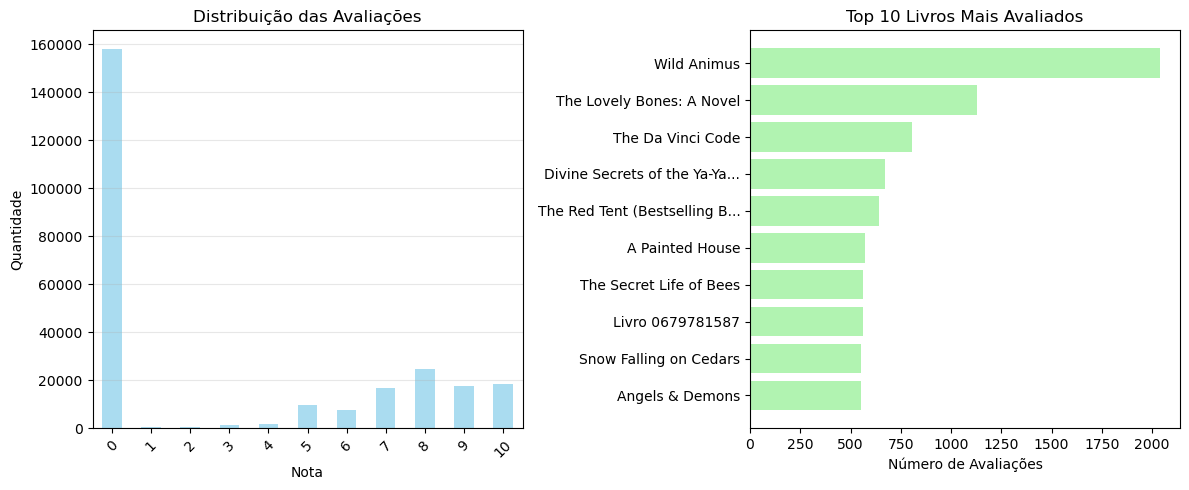


🏆 TOP 10 LIVROS MAIS AVALIADOS:


,Title,Avaliações,Nota Média
0,Wild Animus,2037,0.92
1,The Lovely Bones: A Novel,1129,4.28
2,The Da Vinci Code,804,4.50
3,Divine Secrets of the Ya-Ya...,673,3.32
4,The Red Tent (Bestselling B...,644,4.10
5,A Painted House,572,2.98
6,The Secret Life of Bees,562,4.05
7,Livro 0679781587,560,4.14
8,Snow Falling on Cedars,554,3.06
9,Angels & Demons,553,3.66



📈 ESTATÍSTICAS GERAIS:


,Valor
Total de Livros,3000
Total de Avaliações,256255
Total de Usuários,30028
Avaliações por Livro (média),85.4
Nota Média Geral,3.0
Livros com Títulos,3000/3000



=== 🤖 PREPARANDO MODELOS ===
📚 Dividindo dados em treino e teste...
   - Treino: 205,004 avaliações
   - Teste: 51,251 avaliações
   - Usuários no treino: 27,742
   - Usuários no teste: 14,500

📖 Preparando modelo baseado em conteúdo...
   📝 Usando títulos para similaridade de conteúdo...
   - Matriz TF-IDF: (3000, 500)
   - Livros no modelo: 3000

👥 Preparando modelo colaborativo...
   - Matriz usuário-livro: (27742, 3000)
   - Usuários no modelo: 27742
   - Livros no modelo: 3000
✅ MODELOS PREPARADOS COM SUCESSO!

🎮 INTERFACE INTERATIVA DE RECOMENDAÇÕES
📚 ALGUNS LIVROS DISPONÍVEIS:
   📖 Angelas Ashes
      ISBN: 000649840X | Nota: 3.4 ⭐
   📖 Billy
      ISBN: 0007110928 | Nota: 4.0 ⭐
   📖 Unless : A Novel
      ISBN: 0007154615 | Nota: 2.2 ⭐
   📖 Joshua
      ISBN: 0020198906 | Nota: 2.7 ⭐
   📖 GREAT GATSBY (REISSUE)
      ISBN: 0020199600 | Nota: 4.6 ⭐
   📖 AGE OF INNOCENCE (MOVIE TIE-IN)
      ISBN: 002026478X | Nota: 1.1 ⭐
   📖 Lion, the Witch and the Wardrobe
      ISBN: 0020442

,precision,recall,ndcg,n_users
content,0.013,0.067,0.029,15.0
collaborative,0.031,0.154,0.125,13.0
hybrid,0.053,0.267,0.171,15.0


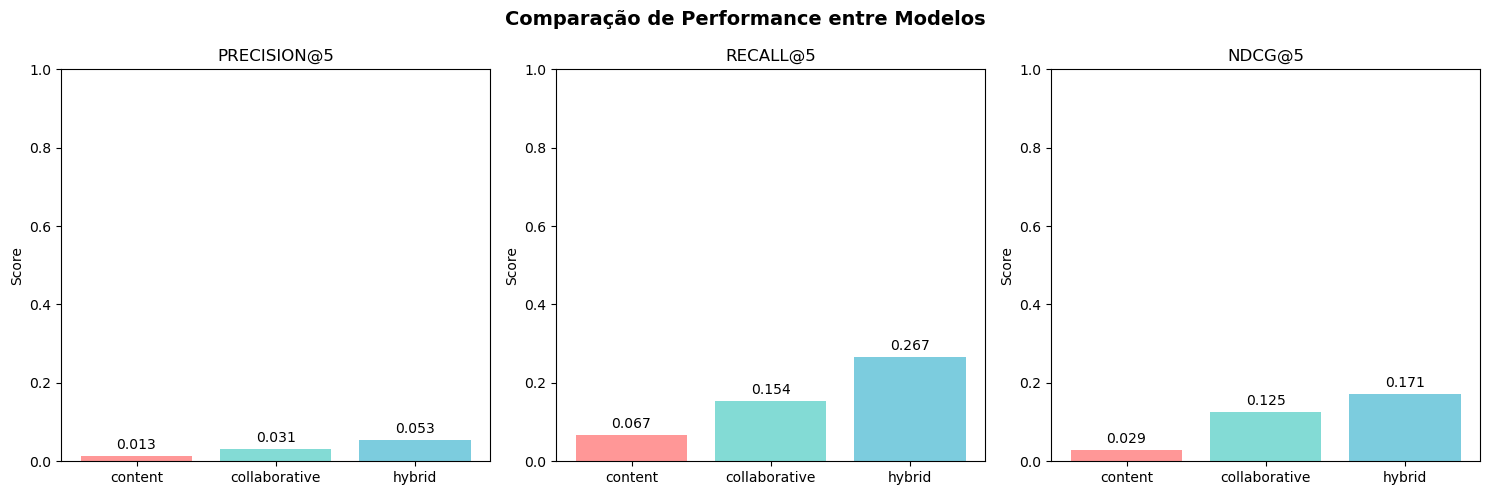


🚀 RECOMENDAÇÕES PARA MELHORIA:
   1. Aumentar quantidade de dados de treinamento
   2. Adicionar mais metadados dos livros (autor, gênero, ano)
   3. Implementar técnicas de deep learning
   4. Otimizar hiperparâmetros dos algoritmos
   5. Adicionar filtros por popularidade e novidade
   6. Implementar sistema de feedback do usuário

✅ SISTEMA CONCLUÍDO COM SUCESSO!


In [96]:
# Célula 15: Execução Completa do Sistema
print("🚀 EXECUÇÃO COMPLETA DO SISTEMA DE RECOMENDAÇÃO")
print("=" * 55)

# 1. Inicializar sistema
recommender = BookRecommendationSystem()

# 2. Carregar dados
success = recommender.load_data(
    ratings_path='../arquivos/Ratings.csv', 
    users_path='../arquivos/Users.csv',
    books_path='../arquivos/Books.csv'  # Adicione seu arquivo de livros
)

if success:
    # 3. Mostrar amostras
    recommender.show_data_samples()
    
    # 4. Pré-processamento
    recommender.preprocess_data()
    
    # 5. Análise exploratória
    recommender.explore_data()
    
    # 6. Preparar modelos
    models_ready = recommender.prepare_models()
    
    if models_ready:
        # 7. Interface interativa
        recommender.interactive_recommendations()
        
        # 8. Testar recomendações
        print("\n" + "="*50)
        print("🧪 TESTE AUTOMÁTICO DE RECOMENDAÇÕES")
        print("="*50)
        
        if hasattr(recommender, 'book_features') and recommender.book_features is not None:
            sample_books = recommender.book_features['ISBN'].head(2).tolist()
            sample_users = recommender.df_ratings['User-ID'].head(2).tolist()

            if sample_books and sample_users:
                hybrid_recs = recommender.hybrid_recommendations(
                    user_id=sample_users[0],
                    book_isbn=sample_books[0],
                    n_recommendations=5
                )
        
        # 9. Avaliação completa
        print("\n" + "="*50)
        print("📊 AVALIAÇÃO DE PERFORMANCE")
        print("="*50)
        
        recommender.generate_report()
        
    else:
        print("❌ Problemas na preparação dos modelos")
else:
    print("❌ Falha ao carregar dados. Verifique os caminhos dos arquivos.")